In [9]:
from bs4 import BeautifulSoup
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
headers = {
    'User-Agent': 'WikiScraper/1.0 (https://github.com/Psyched4Data/Portfolio-Projects/tree/main/Web%20Scraping%20With%20Python; haydongonzalezdyer@gmail.com)'
}
url = 'https://en.wikipedia.org/wiki/List_of_largest_companies_by_revenue'
page = requests.get(url, headers=headers)
soup = BeautifulSoup(page.text, 'html.parser')

In [18]:
print(soup)

<!DOCTYPE html>

<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>List of largest companies by revenue - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom

In [27]:
# Pull data from the table
table = soup.find('table', class_ = 'wikitable')
header_row = table.find('tr')
headers_list = [th.get_text(strip = True) for th in header_row.find_all('th')]
print(table)


<table class="wikitable sortable sticky-header-multi sort-under" style="text-align:left;">
<tbody><tr>
<th rowspan="2" scope="col">Ranks
</th>
<th rowspan="2" scope="col">Name
</th>
<th rowspan="2" scope="col">Industry
</th>
<th scope="col">Revenue
</th>
<th scope="col">Profit
</th>
<th rowspan="2" scope="col">Employees
</th>
<th rowspan="2" scope="col">Headquarters<sup class="reference" id="cite_ref-5"><a href="#cite_note-5"><span class="cite-bracket">[</span>note 1<span class="cite-bracket">]</span></a></sup>
</th>
<th rowspan="2" scope="col"><a href="/wiki/State-owned_enterprise" title="State-owned enterprise">State-owned</a>
</th>
<th class="unsortable" rowspan="2" scope="col"><abbr title="Reference(s)">Ref.</abbr>
</th></tr>
<tr>
<th colspan="2" scope="col"><small>USD (in millions)</small>
</th></tr>
<tr>
<th scope="col">1
</th>
<td><a href="/wiki/Walmart" title="Walmart">Walmart</a></td>
<td><a href="/wiki/Retail" title="Retail">Retail</a></td>
<td style="text-align:center;">$680

In [75]:
# Get headers
header_row = table.find('tr') 
headers_list = [th.get_text(strip=True) for th in header_row.find_all('th')]
headers_list = [h.split('[')[0] if '[' in h else h for h in headers_list]

print(headers_list)

['Ranks', 'Name', 'Industry', 'Revenue', 'Profit', 'Employees', 'Headquarters', 'State-owned', 'Ref.']


In [76]:
df = pd.DataFrame(columns = headers_list)
df

,Ranks,Name,Industry,Revenue,Profit,Employees,Headquarters,State-owned,Ref.


In [79]:
# -----------------------------
# Extract Rows (with rowspan handling)
# -----------------------------
rows = table.find_all("tr")[1:]  # Skip header row
all_rows_data = []
active_rowspans = {}

for row in rows:
    th_cells = row.find_all("th")
    td_cells = row.find_all("td")

    # Skip subheader or empty rows
    if not td_cells:
        continue

    cells = th_cells + td_cells
    row_data = []
    col_index = 0
    cell_index = 0

    while col_index < len(headers_list):

        # If a rowspan is active for this column
        if col_index in active_rowspans:
            row_data.append(active_rowspans[col_index]["value"])
            active_rowspans[col_index]["rows_left"] -= 1

            if active_rowspans[col_index]["rows_left"] == 0:
                del active_rowspans[col_index]

        else:
            if cell_index >= len(cells):
                row_data.append("")  # Safety padding
            else:
                cell = cells[cell_index]

                # Extract text properly
                text = cell.get_text(" ", strip=True)

                # Handle hidden values like Yes/No stored in data-sort-value
                if not text:
                    text = cell.get("data-sort-value", "").strip()

                # Check for rowspan
                rowspan = int(cell.get("rowspan", 1))

                row_data.append(text)

                if rowspan > 1:
                    active_rowspans[col_index] = {
                        "value": text,
                        "rows_left": rowspan - 1
                    }

                cell_index += 1

        col_index += 1

    all_rows_data.append(row_data)

# -----------------------------
# Validation
# -----------------------------
print("\nTotal rows extracted:", len(all_rows_data))
print("First row:", all_rows_data[0])
print("Second row:", all_rows_data[1])



Total rows extracted: 51
First row: ['1', 'Walmart', 'Retail', '$680,985', '$19,436', '2,100,000', 'United States', 'No', '[ 1 ]']
Second row: ['2', 'Amazon', 'Retail Information technology', '$637,959', '$59,248', '1,556,000', 'United States', 'No', '[ 5 ]']
Headers columns: 9, First row columns: 9
Headers: ['Ranks', 'Name', 'Industry', 'Revenue', 'Profit', 'Employees', 'Headquarters', 'State-owned', 'Ref.']
First row: ['1', 'Walmart', 'Retail', '$680,985', '$19,436', '2,100,000', 'United States', 'No', '[ 1 ]']
Second row: ['2', 'Amazon', 'Retail Information technology', '$637,959', '$59,248', '1,556,000', 'United States', 'No', '[ 5 ]']
Headers columns: 9, First row columns: 9


In [80]:
# -----------------------------
# Convert to DataFrame
# -----------------------------
df = pd.DataFrame(all_rows_data, columns=headers_list)

print("\nDataFrame Preview:")
print(df.head())


DataFrame Preview:
  Ranks                                  Name                       Industry  \
0     1                               Walmart                         Retail   
1     2                                Amazon  Retail Information technology   
2     3       State Grid Corporation of China                    Electricity   
3     4                          Saudi Aramco                    Oil and gas   
4     5  China National Petroleum Corporation                    Oil and gas   

    Revenue    Profit  Employees   Headquarters State-owned   Ref.  
0  $680,985   $19,436  2,100,000  United States          No  [ 1 ]  
1  $637,959   $59,248  1,556,000  United States          No  [ 5 ]  
2  $545,948    $9,204  1,361,423          China         Yes  [ 6 ]  
3  $480,446  $106,246     73,311   Saudi Arabia         Yes  [ 7 ]  
4  $476,000   $25,250  1,026,301          China         Yes  [ 8 ]  


In [81]:
df = df.drop(columns=["Ref."])

In [82]:
df.to_csv("fortune_companies.csv", index=False, encoding="utf-8")


/var/folders/xh/kbyxrc692q1gg4j15r1q22nw0000gn/T/ipykernel_95115/3274259133.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=industry_avg.index, y=industry_avg.values, palette="viridis")


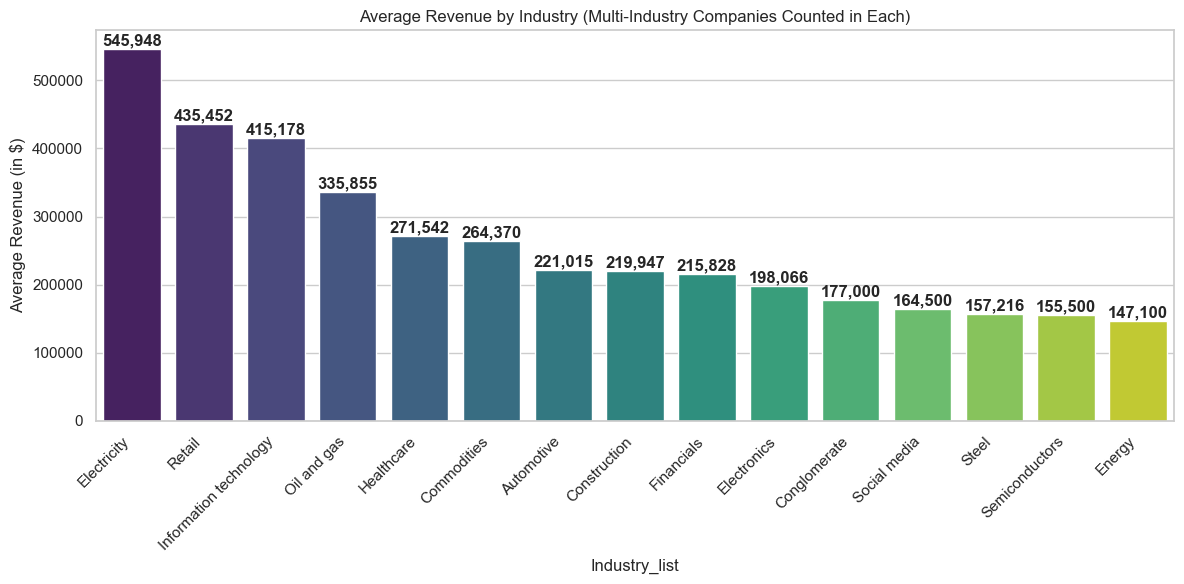

In [89]:
# Graph average Revenue by Industry

# Clean Revenue column
df["Revenue_clean"] = (
    df["Revenue"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Create a list of industries
def split_industries(industry_str):
    # Only split this specific multi-industry company
    if industry_str == "Retail Information technology":
        return ["Retail", "Information technology"]
    else:
        return [industry_str]  # Keep all others as single-item list

df["Industry_list"] = df["Industry"].apply(split_industries)

# Explode so that each company contributes to all industries
df_exploded = df.explode("Industry_list")

# Strip whitespace
df_exploded["Industry_list"] = df_exploded["Industry_list"].str.strip()

# Compute average revenue by industry
industry_avg = (
    df_exploded.groupby("Industry_list")["Revenue_clean"]
    .mean()
    .sort_values(ascending=False)
)

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=industry_avg.index, y=industry_avg.values, palette="viridis")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Revenue (in $)")
plt.title("Average Revenue by Industry (Multi-Industry Companies Counted in Each)")

# Add values above bars
for i, v in enumerate(industry_avg.values):
    ax.text(i, v + 1000, f"{v:,.0f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()